#Iterative Reweighted Least Squares (IRLS) for Logistic Regression

##Goal: Binary classification on MNIST Subset (Classes 0 & 1)

In [1]:
# =============================================
# IRLS Logistic Regression - Full MNIST (0 vs 1)
# =============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

##Sigmoid & IRLS

In [ ]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [2]:
def irls_logistic(X, t, max_iter=40, tol=1e-6, lambda_reg=1e-5):
    N, D = X.shape
    w = np.zeros(D)
    history = []

    for i in range(max_iter):
        y = sigmoid(X @ w)

        R = np.diag(y * (1 - y) + 1e-8)
        grad = X.T @ (y - t)
        Hessian = X.T @ R @ X + lambda_reg * np.eye(D)

        w_new = w - np.linalg.solve(Hessian, grad)

        delta = np.linalg.norm(w_new - w)
        history.append(delta)
        w = w_new

        if delta < tol:
            print(f"✅ Converged after {i+1} iterations")
            break
    else:
        print("Reached maximum iterations")

    return w, history

##Load FULL MNIST Subset (Classes 0 & 1)

In [3]:
print("Downloading full MNIST...")

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X_full = mnist.data.astype(float)
y_full = mnist.target.astype(int)

# Select only digits 0 and 1
mask = (y_full == 0) | (y_full == 1)
X = X_full[mask]
t = (y_full[mask] == 1).astype(float)

print(f"Full Dataset: {X.shape[0]} samples, {X.shape[1]} features")

# Take subset for speed
# n_samples = 5000
# np.random.seed(42)
# idx = np.random.choice(len(X), n_samples, replace=False)
# X = X[idx]
# t = t[idx]
# print(f"Subset Dataset: {X.shape[0]} samples, {X.shape[1]} features")

# Normalize
X = X / 255.0

# Add bias term
X_bias = np.c_[np.ones(len(X)), X]

print("Data ready for full training!")

Full Dataset: 14780 samples, 784 features
Data ready for full training!


##Training & Evaluation

Training IRLS on FULL dataset... This may take a while...
Reached maximum iterations

🎯 Final Accuracy on Full Data: 100.00%


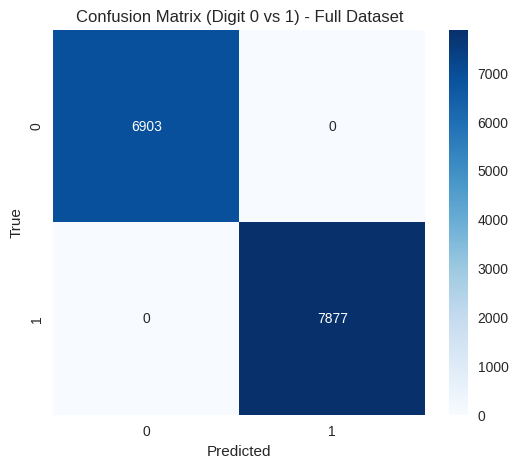

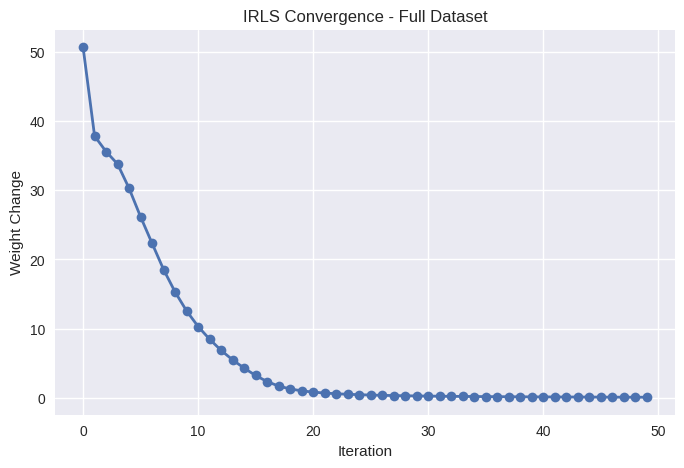

In [4]:
print("Training IRLS on FULL dataset... This may take a while...")

w, history = irls_logistic(X_bias, t, max_iter=50, tol=1e-6, lambda_reg=1e-5)

# Predictions
y_prob = sigmoid(X_bias @ w)
y_pred = (y_prob >= 0.5).astype(int)

# Results
acc = accuracy_score(t, y_pred) * 100
print(f"\n🎯 Final Accuracy on Full Data: {acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(t, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Digit 0 vs 1) - Full Dataset')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Convergence
plt.figure(figsize=(8,5))
plt.plot(history, 'o-', linewidth=2)
plt.title('IRLS Convergence - Full Dataset')
plt.xlabel('Iteration')
plt.ylabel('Weight Change')
plt.grid(True)
plt.show()

- This uses the complete set of digits 0 and 1 from MNIST (around 14k+ samples).
- Colab should handle it fine.
- If it becomes slow on your device, you can reduce max_iter or increase regularization (lambda_reg).